# Week 8 - Monte Carlo Methods: First-Visit Prediction

Based on Sutton & Barto, Chapter 5, mainly Section 5.1.

## Learning goals

- Understand the transition from Dynamic Programming to Monte Carlo methods.
- Learn how values can be estimated from sampled episodes.
- Implement First-Visit Monte Carlo Prediction.
- Compare Monte Carlo estimates with Dynamic Programming Policy Evaluation.

## Recap: from Dynamic Programming to Monte Carlo

In Weeks 5 to 7, the Gridworld was treated as a known Markov Decision Process. Dynamic Programming methods used the model directly through Bellman updates.

**Dynamic Programming:** uses the known model to compute expected updates.

**Monte Carlo:** uses sampled experience to estimate expected returns.

This means Monte Carlo prediction does not need the transition model `p(s', r | s, a)`; it only needs complete episodes generated by interaction with the environment.

## Prediction problem

Week 8 is still a **prediction** problem, not a control problem. The policy stays fixed.

The question is:

How good is each state under a fixed policy `pi`?

The target quantity is the state-value function

v<sub>&pi;</sub>(s) = E<sub>&pi;</sub>[ G<sub>t</sub> | S<sub>t</sub> = s ]

We will estimate v<sub>&pi;</sub>(s) from sampled episodes and use `V(s)` for the Monte Carlo estimate.

## Returns and episodes

A Monte Carlo method works with full episodes. An episode is a trajectory of states, actions, and rewards until termination or truncation.

The return from time step `t` is

G<sub>t</sub> = R<sub>t+1</sub> + &gamma; R<sub>t+2</sub> + &gamma;<sup>2</sup> R<sub>t+3</sub> + ...

Monte Carlo prediction waits until the episode ends, then computes these returns backward from the observed rewards.

## First-Visit Monte Carlo Prediction

For each episode, First-Visit MC updates a state only the **first** time that state appears in the episode. Every-Visit MC would update every occurrence, but this notebook implements **First-Visit MC only**.

Pseudocode:

1. Generate an episode under the fixed policy `pi`.
2. Compute the returns G<sub>t</sub> backward through the episode.
3. For each state S<sub>t</sub>:
   - if S<sub>t</sub> has not appeared earlier in the episode, record G<sub>t</sub>
   - update `V(S_t)` as the average of recorded returns
4. Repeat for many episodes.

## Imports and setup

The next cell imports the existing Gridworld components, loads the new Monte Carlo helpers, and prepares the standard `results/week_08/` directory for saved figures.

In [1]:
import importlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display

project_root = Path.cwd()
if not (project_root / 'src').exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.gridworld.environment import GridworldMDP
from src.gridworld.policies import GoalDirectedPolicy
from src.gridworld.policy_evaluation import iterative_policy_evaluation, values_to_grid
from src.monte_carlo import compute_returns, first_visit_mc_prediction, generate_episode
import src.utils.plotting as plotting

plotting = importlib.reload(plotting)

plot_trajectory_on_grid = plotting.plot_trajectory_on_grid
plot_value_function_grid = plotting.plot_value_function_grid

results_dir = project_root / 'results' / 'week_08'
results_dir.mkdir(parents=True, exist_ok=True)

plt.style.use('default')
np.set_printoptions(precision=3, suppress=True)


def episode_to_state_path(env, episode):
    if not episode:
        return []

    states = [episode[0][0]]
    current_state = episode[0][0]
    for state, action, _reward in episode:
        next_state, _reward_value, _done, _info = env.get_transition(current_state, action)
        states.append(next_state)
        current_state = next_state
    return states


def draw_value_grid(ax, value_grid, env, title, cmap_name='RdYlGn', colorbar_label='Value'):
    cmap = plt.cm.get_cmap(cmap_name).copy()
    cmap.set_bad(color='lightgray')
    image = ax.imshow(value_grid, cmap=cmap, origin='upper')
    ax.set_title(title)
    ax.set_xlabel('Column')
    ax.set_ylabel('Row')
    ax.set_xticks(range(env.grid_size[1]))
    ax.set_yticks(range(env.grid_size[0]))

    for row in range(env.grid_size[0]):
        for col in range(env.grid_size[1]):
            state = (row, col)
            if state in env.obstacles:
                ax.text(col, row, 'X', ha='center', va='center', fontsize=11, fontweight='bold')
                continue

            value = value_grid[row, col]
            label = '' if np.isnan(value) else f'{value:.2f}'
            marker = ''
            if state == env.start_state:
                marker = '\nS'
            elif state == env.goal_state:
                marker = '\nG'
            ax.text(col, row, label + marker, ha='center', va='center', fontsize=7)

    return image, colorbar_label


def plot_dp_mc_comparison(mc_grid, dp_grid, error_grid, env, save_path):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

    image, label = draw_value_grid(axes[0], mc_grid, env, 'Monte Carlo Estimate', colorbar_label='V(s)')
    fig.colorbar(image, ax=axes[0], label=label, shrink=0.82, pad=0.03)

    image, label = draw_value_grid(axes[1], dp_grid, env, 'DP Reference', colorbar_label='V(s)')
    fig.colorbar(image, ax=axes[1], label=label, shrink=0.82, pad=0.03)

    image, label = draw_value_grid(axes[2], error_grid, env, 'Absolute Error |MC - DP|', cmap_name='Blues', colorbar_label='Absolute Error')
    fig.colorbar(image, ax=axes[2], label=label, shrink=0.82, pad=0.03)

    fig.suptitle('First-Visit Monte Carlo vs Dynamic Programming')
    fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close(fig)


## Gridworld setup

We reuse the same Gridworld from the earlier weeks. The key difference is how it is used: for Monte Carlo prediction, the environment is treated as an **interactive sampler** that produces episodes.

To improve state coverage, the Monte Carlo helper starts episodes from randomly sampled valid non-terminal states while still following the same fixed policy after that.

In [2]:
env = GridworldMDP()
gamma = 1.0
max_steps = 100
num_episodes = 5000

policy = GoalDirectedPolicy(
    goal_state=env.goal_state,
    grid_size=env.grid_size,
    obstacles=env.obstacles,
    exploration_prob=0.1,
    seed=42,
)

print(f'Grid size: {env.grid_size}')
print(f'Start state: {env.start_state}')
print(f'Goal state: {env.goal_state}')
print(f'Obstacles: {sorted(env.obstacles)}')
print(f'Number of valid states: {len(env.get_all_states())}')
print(f'Number of non-terminal states: {len(env.get_non_terminal_states())}')
print('Policy: GoalDirectedPolicy with exploration_prob = 0.1')

Grid size: (5, 5)
Start state: (0, 0)
Goal state: (4, 4)
Obstacles: [(1, 1), (1, 3), (2, 3), (3, 0), (4, 2)]
Number of valid states: 20
Number of non-terminal states: 19
Policy: GoalDirectedPolicy with exploration_prob = 0.1


## Generate a sample episode

Before running many episodes, it helps to inspect one sampled trajectory. The next cell generates a single episode from the start state, records transitions as (S<sub>t</sub>, A<sub>t</sub>, R<sub>t+1</sub>), and plots the visited path on the grid.

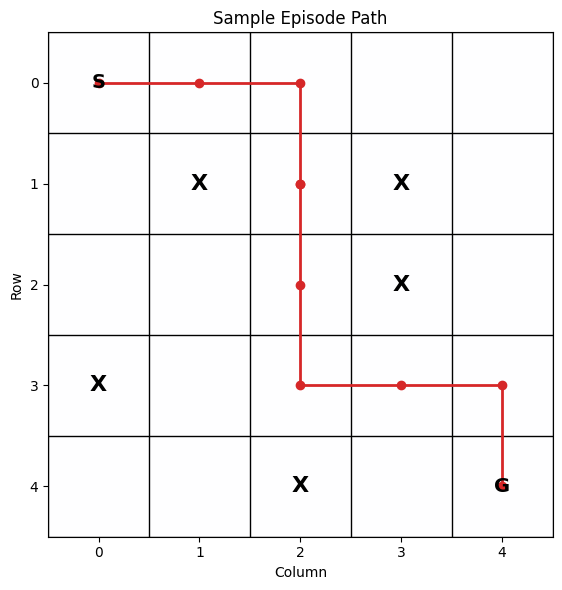

Episode length: 9
First five transitions:
((0, 0), 'right', -1.0)
((0, 1), 'right', -1.0)
((0, 2), 'down', -1.0)
((1, 2), 'left', -5.0)
((1, 2), 'down', -1.0)
Terminal state reached: True
Final state: (4, 4)


In [3]:
sample_episode = generate_episode(
    env=env,
    policy=policy,
    max_steps=max_steps,
    start_state=env.start_state,
)

sample_states = episode_to_state_path(env, sample_episode)
plot_trajectory_on_grid(
    {'states': sample_states},
    env,
    title='Sample Episode Path',
    save_path=results_dir / 'sample_episode_path.png',
)

print('Episode length:', len(sample_episode))
print('First five transitions:')
for transition in sample_episode[:5]:
    print(transition)

print('Terminal state reached:', sample_states[-1] == env.goal_state if sample_states else False)
print('Final state:', sample_states[-1] if sample_states else None)

## Compute returns for the sample episode

Monte Carlo prediction needs the return G<sub>t</sub> aligned with each time step. The next cell computes returns backward from the sampled rewards so each transition (S<sub>t</sub>, A<sub>t</sub>, R<sub>t+1</sub>) is paired with its return G<sub>t</sub>.

In [4]:
sample_returns = compute_returns(sample_episode, gamma=gamma)

print('First five (state, action, reward, return) tuples:')
for (state, action, reward), return_t in list(zip(sample_episode, sample_returns))[:5]:
    print(f'S_t={state}, A_t={action}, R_t+1={reward:.1f}, G_t={return_t:.2f}')

print('Return from the first time step G_0:', round(sample_returns[0], 3) if sample_returns else None)

First five (state, action, reward, return) tuples:
S_t=(0, 0), A_t=right, R_t+1=-1.0, G_t=-2.00
S_t=(0, 1), A_t=right, R_t+1=-1.0, G_t=-1.00
S_t=(0, 2), A_t=down, R_t+1=-1.0, G_t=0.00
S_t=(1, 2), A_t=left, R_t+1=-5.0, G_t=1.00
S_t=(1, 2), A_t=down, R_t+1=-1.0, G_t=6.00
Return from the first time step G_0: -2.0


## Implement First-Visit MC prediction

Now we run First-Visit Monte Carlo prediction for many episodes. Each episode is generated under the fixed policy. For a state S<sub>t</sub>, we only use the return G<sub>t</sub> from the **first** occurrence of that state within that episode.

This produces an empirical estimate `V(s)` by averaging observed returns following first visits.

In [5]:
mc_values, mc_history = first_visit_mc_prediction(
    env=env,
    policy=policy,
    num_episodes=num_episodes,
    gamma=gamma,
    max_steps=max_steps,
    seed=42,
)

mc_grid = values_to_grid(mc_values, env)
visited_states = sum(1 for count in mc_history['returns_count'].values() if count > 0)
mean_episode_length = float(np.mean(mc_history['episode_lengths']))
mean_episode_return = float(np.mean(mc_history['episode_returns']))

print(f'Episodes sampled: {num_episodes}')
print(f'States with at least one first-visit update: {visited_states}')
print(f'Average episode length: {mean_episode_length:.2f}')
print(f'Average episode return: {mean_episode_return:.2f}')

Episodes sampled: 5000
States with at least one first-visit update: 19
Average episode length: 6.22
Average episode return: 3.86


## Visualize the Monte Carlo value estimates

After many episodes, the First-Visit MC estimate provides a full state-value grid. Higher values should appear near parts of the grid from which the fixed policy can reach the goal efficiently.

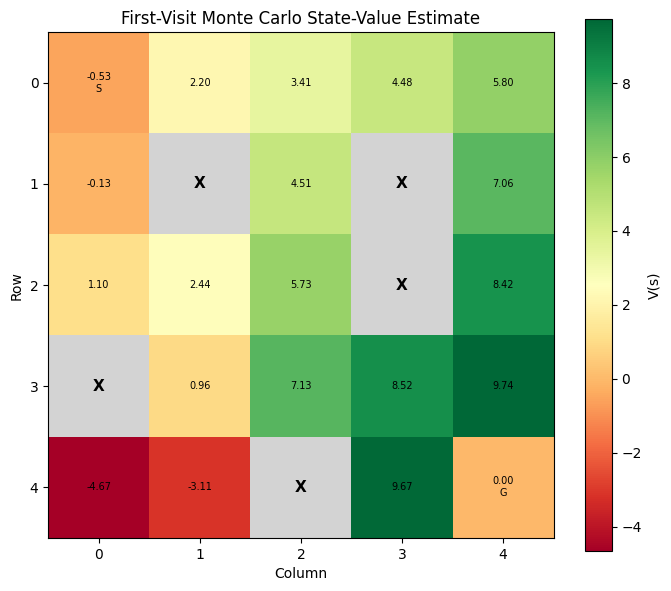

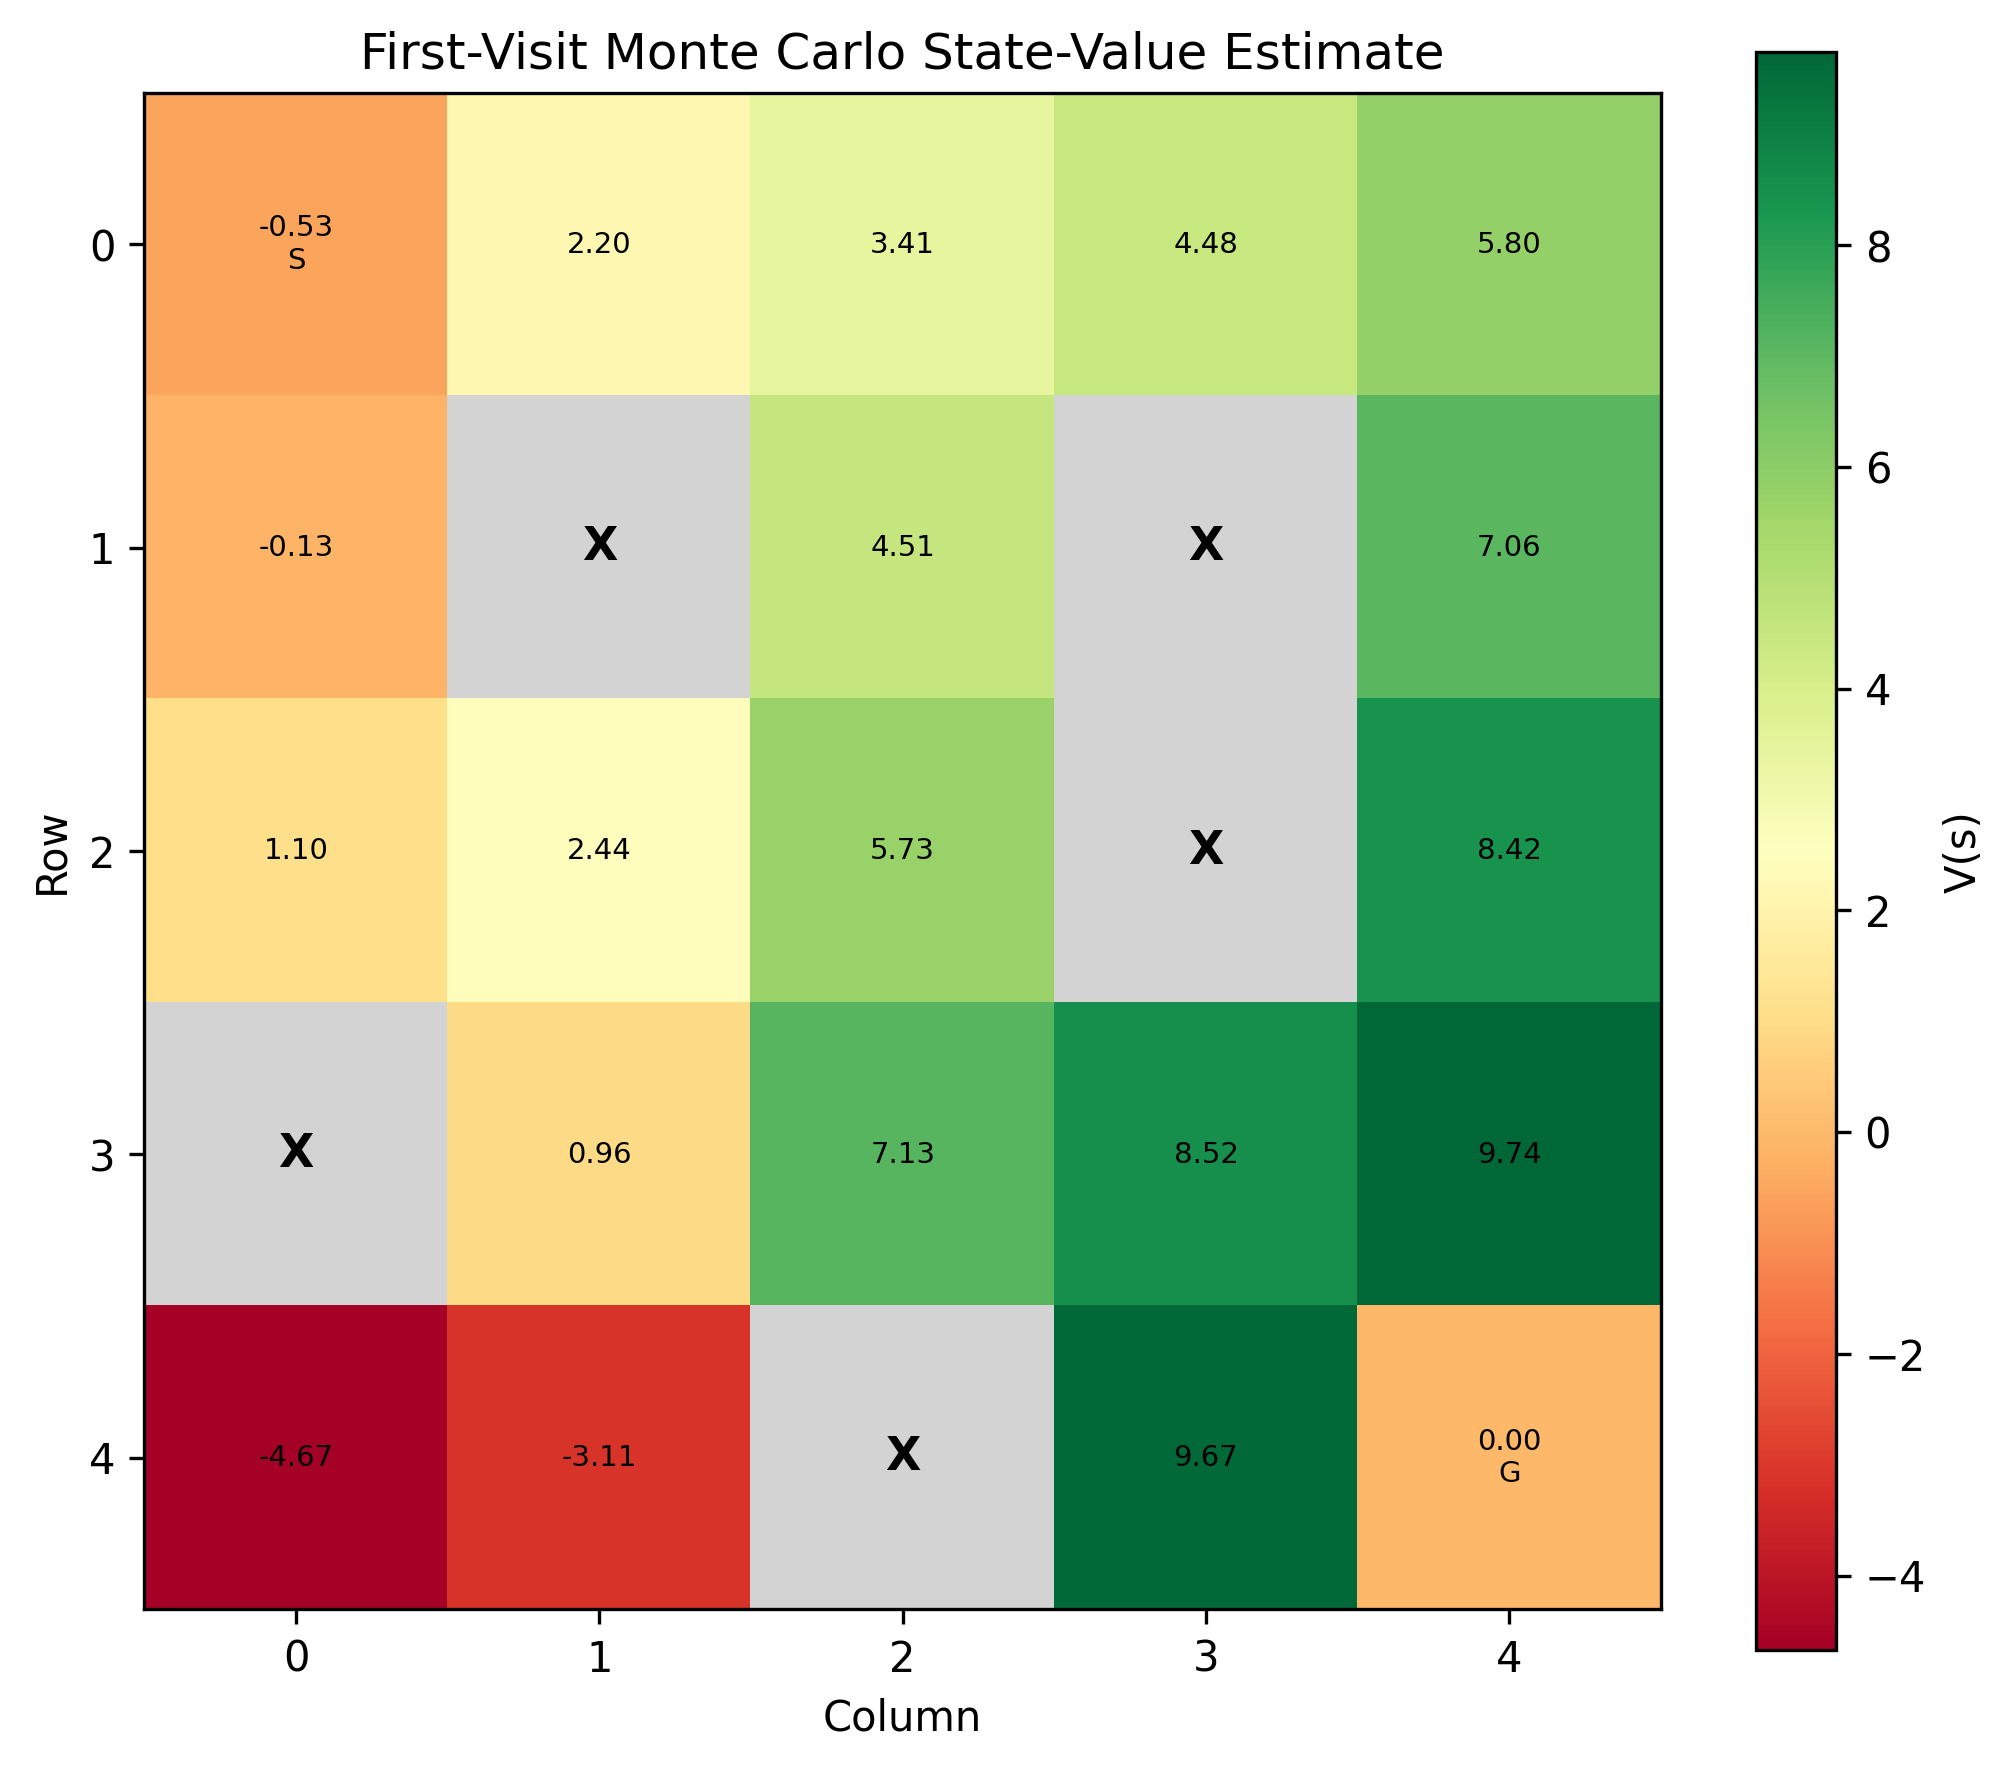

array([[-0.531,  2.198,  3.409,  4.476,  5.802],
       [-0.127,    nan,  4.509,    nan,  7.063],
       [ 1.102,  2.436,  5.731,    nan,  8.424],
       [   nan,  0.958,  7.126,  8.519,  9.74 ],
       [-4.668, -3.11 ,    nan,  9.668,  0.   ]])

In [6]:
plot_value_function_grid(
    mc_grid,
    env,
    title='First-Visit Monte Carlo State-Value Estimate',
    save_path=results_dir / 'mc_value_estimates.png',
)

display(Image(filename=results_dir / 'mc_value_estimates.png'))

mc_grid

## Compare with Dynamic Programming policy evaluation

Dynamic Programming and Monte Carlo are estimating the same value function v<sub>&pi;</sub>(s) under the same fixed policy, but with different information. DP uses the known model and Bellman expectation backups. MC uses sampled episodes and averages observed returns.

The next cell computes the Week 5 DP reference value function, then compares it with the Week 8 MC estimate using both a value-grid view and an absolute error grid.

C:\Users\svaid\AppData\Local\Temp\ipykernel_2796\3638041624.py:47: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name).copy()


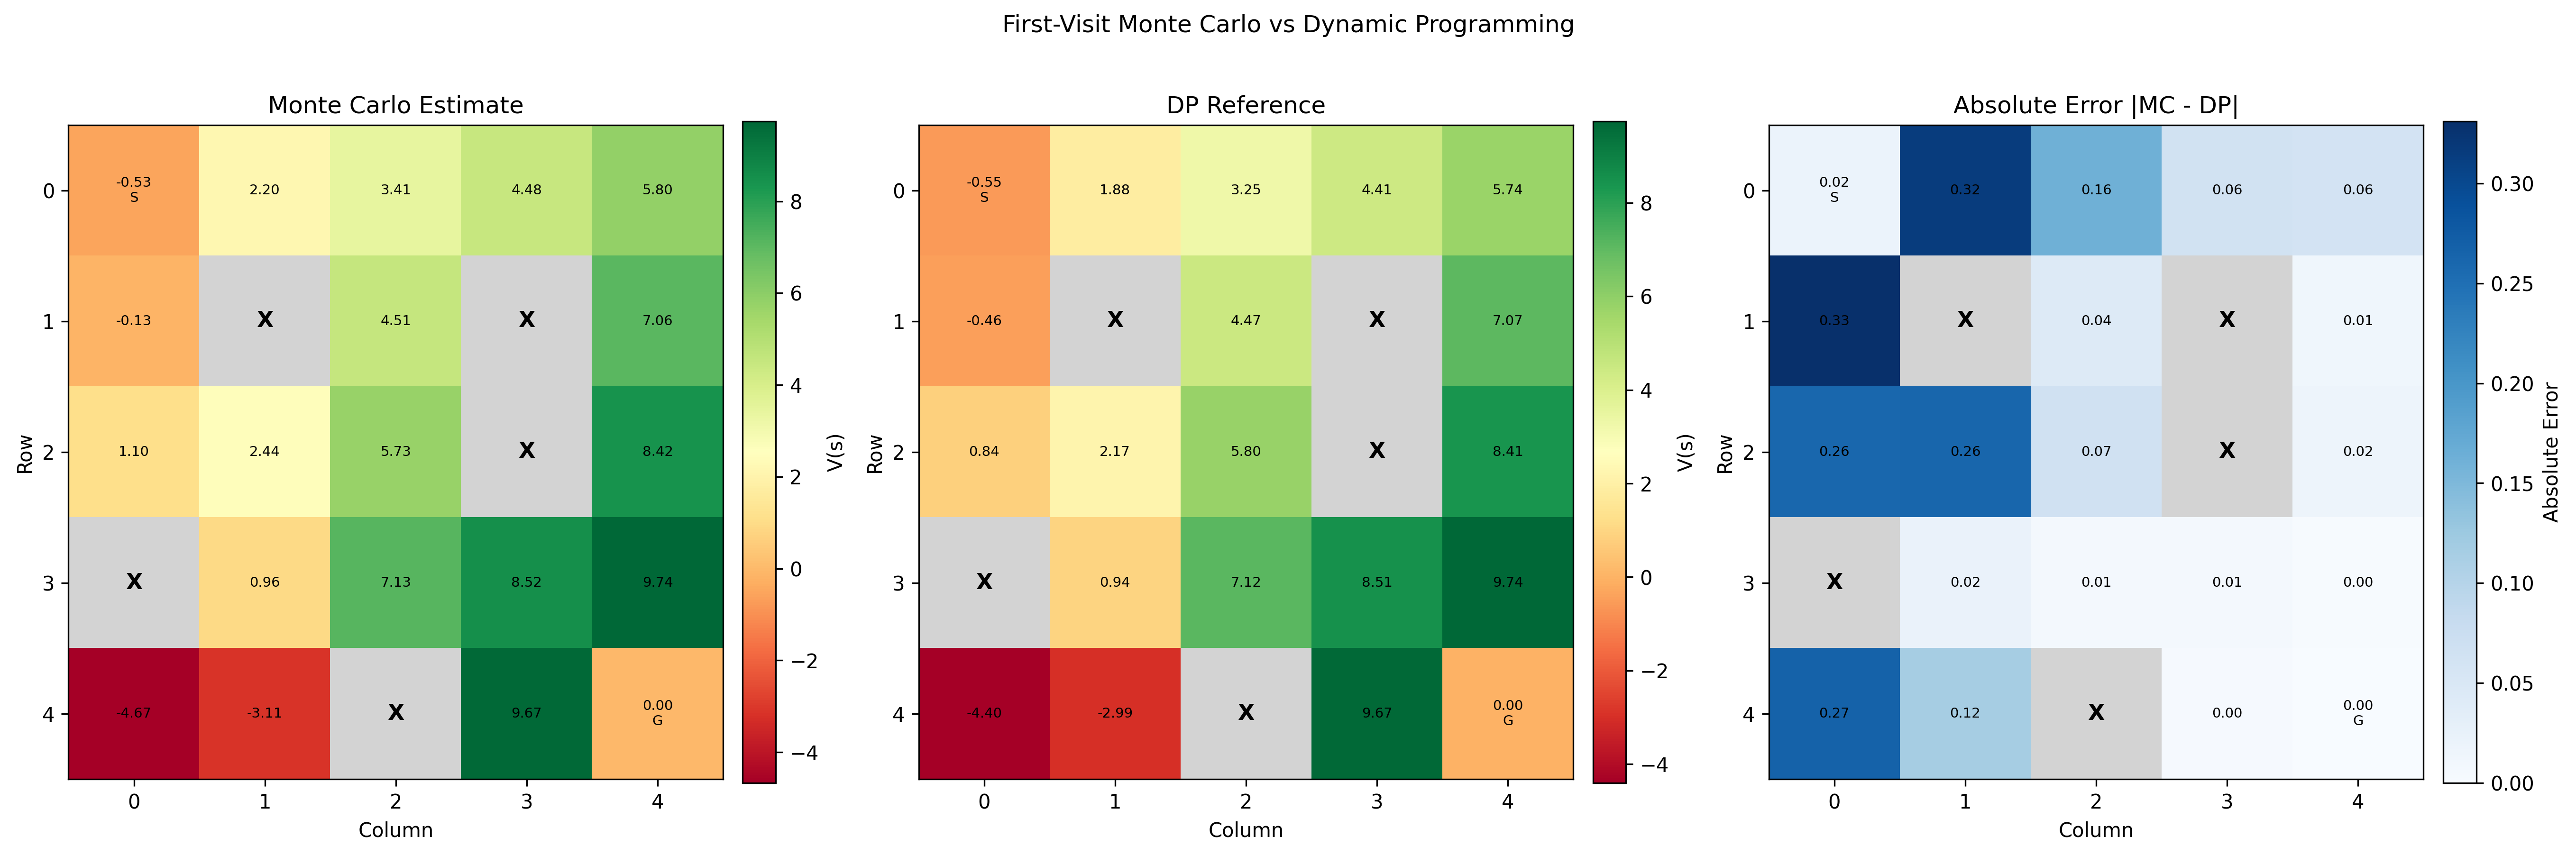

DP sweeps: 64
Mean absolute error between MC and DP: 0.107


In [7]:
dp_values, dp_history = iterative_policy_evaluation(
    env=env,
    policy=policy,
    gamma=gamma,
    theta=1e-4,
    max_iterations=1000,
)

dp_grid = values_to_grid(dp_values, env)
error_grid = np.abs(mc_grid - dp_grid)
for obstacle in env.obstacles:
    error_grid[obstacle] = np.nan

non_terminal_states = [state for state in env.get_non_terminal_states()]
mae = float(np.mean([abs(mc_values[state] - dp_values[state]) for state in non_terminal_states]))

plot_dp_mc_comparison(
    mc_grid=mc_grid,
    dp_grid=dp_grid,
    error_grid=error_grid,
    env=env,
    save_path=results_dir / 'dp_vs_mc_values.png',
)

display(Image(filename=results_dir / 'dp_vs_mc_values.png'))

print('DP sweeps:', len(dp_history))
print('Mean absolute error between MC and DP:', round(mae, 4))

## Plot error over episodes

A useful way to see convergence is to compare Monte Carlo snapshots with the DP reference values. The helper already stores value snapshots during training, so we can compute the mean absolute error after different numbers of sampled episodes.

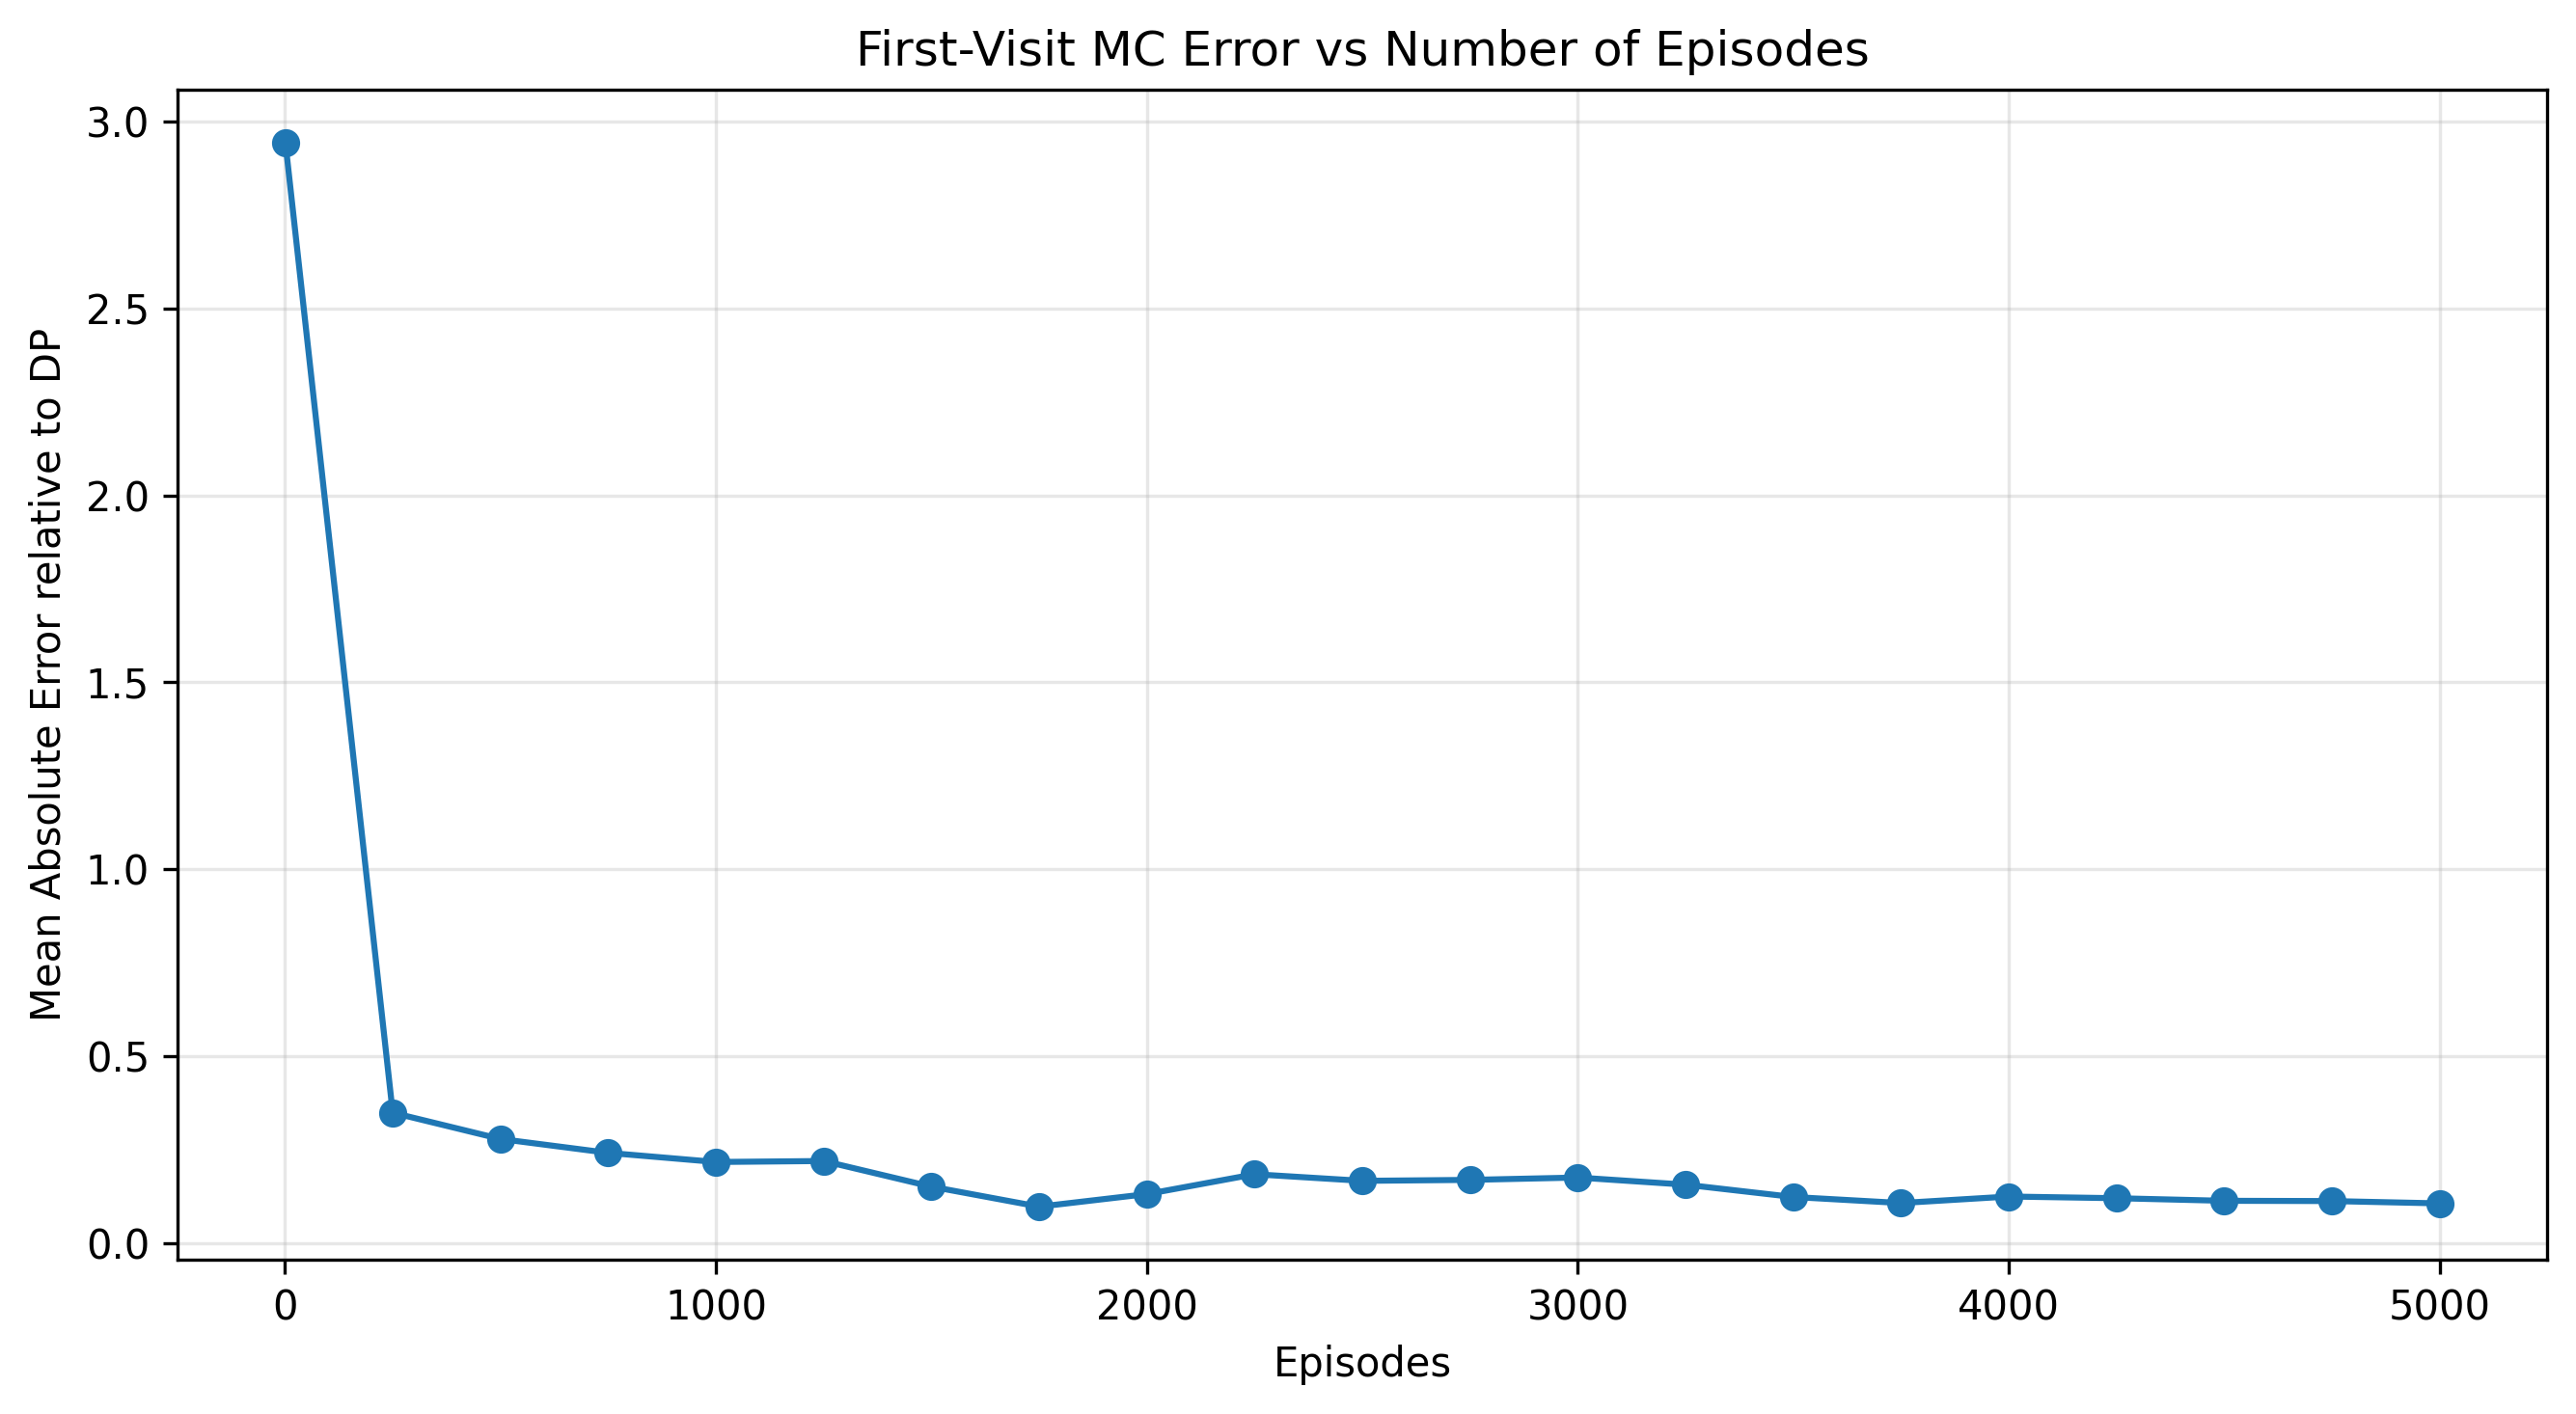

Snapshot episodes: [1, 250, 500, 750, 1000] ...
Last five MAE values: [np.float64(0.1253), np.float64(0.1208), np.float64(0.1139), np.float64(0.1132), np.float64(0.107)]


In [8]:
snapshot_episodes = []
snapshot_mae = []

for snapshot in mc_history['value_snapshots']:
    snapshot_episodes.append(snapshot['episode'])
    snapshot_values = snapshot['values']
    snapshot_mae.append(
        np.mean([abs(snapshot_values[state] - dp_values[state]) for state in non_terminal_states])
    )

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(snapshot_episodes, snapshot_mae, marker='o')
ax.set_title('First-Visit MC Error vs Number of Episodes')
ax.set_xlabel('Episodes')
ax.set_ylabel('Mean Absolute Error relative to DP')
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(results_dir / 'mc_error_over_episodes.png', dpi=300, bbox_inches='tight')
plt.close(fig)

display(Image(filename=results_dir / 'mc_error_over_episodes.png'))

print('Snapshot episodes:', snapshot_episodes[:5], '...')
print('Last five MAE values:', [round(value, 4) for value in snapshot_mae[-5:]])

## Key takeaways

- DP uses a known model.
- Monte Carlo learns from complete sampled episodes.
- First-Visit MC updates each state once per episode.
- MC estimates values by averaging observed returns.
- MC does not bootstrap.
- This prepares the transition toward Temporal-Difference learning.